In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
import os
os.listdir("../data")

['movie-recommendation-hackathon-2026']

In [3]:
os.listdir("../data/movie-recommendation-hackathon-2026")

['genome_scores.csv',
 'genome_tags.csv',
 'imdb_data.csv',
 'links.csv',
 'movies.csv',
 'sample_submission.csv',
 'tags.csv',
 'test.csv',
 'train.csv']

In [4]:
train = pd.read_csv("../data/movie-recommendation-hackathon-2026/train.csv")
test = pd.read_csv("../data/movie-recommendation-hackathon-2026/test.csv")
movies = pd.read_csv("../data/movie-recommendation-hackathon-2026/movies.csv")
imdb = pd.read_csv("../data/movie-recommendation-hackathon-2026/imdb_data.csv")
links = pd.read_csv("../data/movie-recommendation-hackathon-2026/links.csv")
tags = pd.read_csv("../data/movie-recommendation-hackathon-2026/tags.csv")

In [5]:
print("Dataset Shapes")
print("-" * 40)

print(f"Train dataset : {train.shape}")
print(f"Test dataset  : {test.shape}")
print(f"Movies dataset: {movies.shape}")
print(f"IMDb dataset  : {imdb.shape}")
print(f"Links dataset : {links.shape}")
print(f"Tags dataset  : {tags.shape}")

Dataset Shapes
----------------------------------------
Train dataset : (10000038, 4)
Test dataset  : (5000019, 2)
Movies dataset: (62423, 3)
IMDb dataset  : (27278, 6)
Links dataset : (62423, 3)
Tags dataset  : (1093360, 4)


In [6]:
for name, df in [
    ("Train", train),
    ("Test", test),
    ("Movies", movies),
    ("IMDb", imdb),
    ("Links", links),
    ("Tags", tags)
]:
    print(f"\n{name} Dataset")
    print("-" * 30)
    print(df.columns.tolist())


Train Dataset
------------------------------
['userId', 'movieId', 'rating', 'timestamp']

Test Dataset
------------------------------
['userId', 'movieId']

Movies Dataset
------------------------------
['movieId', 'title', 'genres']

IMDb Dataset
------------------------------
['movieId', 'title_cast', 'director', 'runtime', 'budget', 'plot_keywords']

Links Dataset
------------------------------
['movieId', 'imdbId', 'tmdbId']

Tags Dataset
------------------------------
['userId', 'movieId', 'tag', 'timestamp']


In [7]:
train.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [8]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
imdb.head()

,movieId,title_cast,director,runtime,budget,plot_keywords
0,1,Tom Hanks|Tim Allen|Don Rickles|Jim Varney|Wal...,John Lasseter,81.0,"$30,000,000",toy|rivalry|cowboy|cgi animation
1,2,Robin Williams|Jonathan Hyde|Kirsten Dunst|Bra...,Jonathan Hensleigh,104.0,"$65,000,000",board game|adventurer|fight|game
2,3,Walter Matthau|Jack Lemmon|Sophia Loren|Ann-Ma...,Mark Steven Johnson,101.0,"$25,000,000",boat|lake|neighbor|rivalry
3,4,Whitney Houston|Angela Bassett|Loretta Devine|...,Terry McMillan,124.0,"$16,000,000",black american|husband wife relationship|betra...
4,5,Steve Martin|Diane Keaton|Martin Short|Kimberl...,Albert Hackett,106.0,"$30,000,000",fatherhood|doberman|dog|mansion


In [10]:
train["rating"].describe()

count    1.000004e+07
mean     3.533395e+00
std      1.061124e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

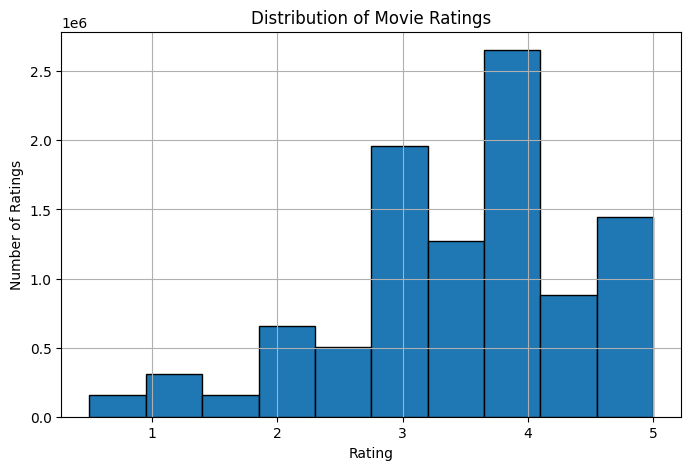

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

train["rating"].hist(bins=10, edgecolor="black")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

In [12]:
movie_rating_counts = (
    train.groupby("movieId")["rating"]
    .count()
    .sort_values(ascending=False)
)

In [13]:
movie_rating_counts.head(10)

movieId
318     32831
356     32383
296     31697
593     29444
2571    29014
260     27560
480     25518
527     24004
110     23722
2959    23536
Name: rating, dtype: int64

In [14]:
# Convert the Series into a DataFrame
movie_rating_counts = movie_rating_counts.reset_index()

# Rename the column
movie_rating_counts.columns = ["movieId", "rating_count"]

# Merge with the movies dataset
popular_movies = movie_rating_counts.merge(
    movies,
    on="movieId"
)

# Display the top 10
popular_movies.head(10)

,movieId,rating_count,title,genres
0,318,32831,"Shawshank Redemption, The (1994)",Crime|Drama
1,356,32383,Forrest Gump (1994),Comedy|Drama|Romance|War
2,296,31697,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,593,29444,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,2571,29014,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,260,27560,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,480,25518,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
7,527,24004,Schindler's List (1993),Drama|War
8,110,23722,Braveheart (1995),Action|Drama|War
9,2959,23536,Fight Club (1999),Action|Crime|Drama|Thriller


In [15]:
user_rating_counts = (
    train.groupby("userId")["rating"]
    .count()
    .sort_values(ascending=False)
)

user_rating_counts.head(10)

userId
72315     12952
80974      3680
137293     3588
33844      3208
20055      3050
109731     2671
49403      2670
92046      2579
110971     2288
30879      2284
Name: rating, dtype: int64

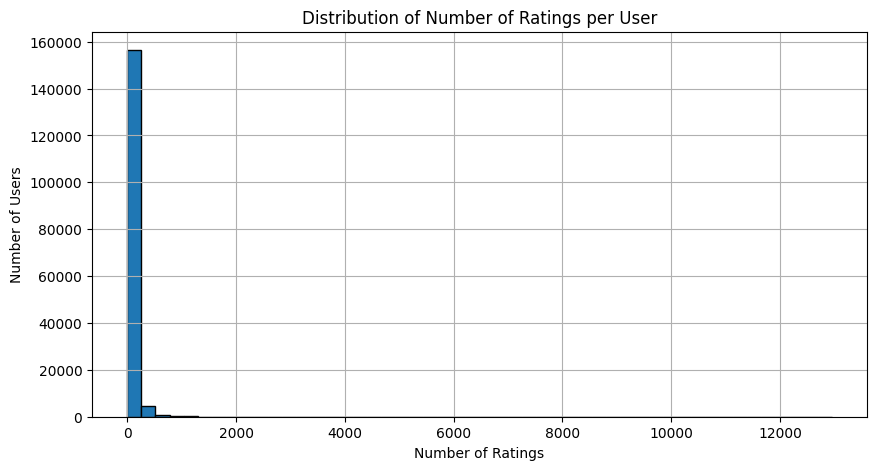

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

user_rating_counts.hist(bins=50, edgecolor="black")

plt.title("Distribution of Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

In [17]:
print("Missing Values in Train Dataset")
print(train.isnull().sum())

print("\n" + "-"*40 + "\n")

print("Missing Values in Movies Dataset")
print(movies.isnull().sum())

print("\n" + "-"*40 + "\n")

print("Missing Values in IMDb Dataset")
print(imdb.isnull().sum())

Missing Values in Train Dataset
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

----------------------------------------

Missing Values in Movies Dataset
movieId    0
title      0
genres     0
dtype: int64

----------------------------------------

Missing Values in IMDb Dataset
movieId              0
title_cast       10068
director          9874
runtime          12089
budget           19372
plot_keywords    11078
dtype: int64


In [18]:
# Split genres into separate values
genres = movies["genres"].str.split("|")

# Flatten the list of genres
all_genres = genres.explode()

# Count each genre
genre_counts = all_genres.value_counts()

# Display the top 10 genres
genre_counts.head(10)

genres
Drama                 25606
Comedy                16870
Thriller               8654
Romance                7719
Action                 7348
Horror                 5989
Documentary            5605
Crime                  5319
(no genres listed)     5062
Adventure              4145
Name: count, dtype: int64

In [19]:
movie_stats = (
    train
    .groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

movie_stats.head()

,movieId,average_rating,rating_count
0,1,3.889971,23062
1,2,3.263414,9654
2,3,3.132325,4727
3,4,2.878099,968
4,5,3.059165,4648


In [20]:
popular_movies = movie_stats.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId"
)

popular_movies.head()

,movieId,average_rating,rating_count,title,genres
0,1,3.889971,23062,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.263414,9654,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.132325,4727,Grumpier Old Men (1995),Comedy|Romance
3,4,2.878099,968,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.059165,4648,Father of the Bride Part II (1995),Comedy


In [21]:
popular_movies.sort_values(
    by=["rating_count", "average_rating"],
    ascending=False
).head(10)

,movieId,average_rating,rating_count,title,genres
314,318,4.417624,32831,"Shawshank Redemption, The (1994)",Crime|Drama
351,356,4.047216,32383,Forrest Gump (1994),Comedy|Drama|Romance|War
292,296,4.195097,31697,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
585,593,4.144172,29444,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
2479,2571,4.154253,29014,"Matrix, The (1999)",Action|Sci-Fi|Thriller
257,260,4.111811,27560,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
475,480,3.684634,25518,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
522,527,4.247625,24004,Schindler's List (1993),Drama|War
108,110,3.994119,23722,Braveheart (1995),Action|Drama|War
2866,2959,4.227906,23536,Fight Club (1999),Action|Crime|Drama|Thriller


In [22]:
sample_train = train[train["userId"] <= 5000]

In [23]:
sample_train.shape

(293516, 4)

In [24]:
print("Unique Users :", sample_train["userId"].nunique())
print("Unique Movies:", sample_train["movieId"].nunique())
print("Total Ratings:", len(sample_train))

Unique Users : 5000
Unique Movies: 14725
Total Ratings: 293516


In [25]:
sample_train = train[train["userId"] <= 1000]

print("Unique Users :", sample_train["userId"].nunique())
print("Unique Movies:", sample_train["movieId"].nunique())
print("Total Ratings:", len(sample_train))

Unique Users : 1000
Unique Movies: 8213
Total Ratings: 57238


In [26]:
user_movie_matrix = sample_train.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_movie_matrix.head()

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      11      12      13      14      15      16      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  17      18      19      20      21      22      23      24      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  25      26      27      28      29      30      31      32      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     4.5   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     5.0   

movieId  34      35      36      37      39      40      41      42      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  43      44      45      46      47      48      50      51      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     5.0     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     5.0     NaN     5.0     NaN   

movieId  52      54      55      56      57      58      60      61      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  62      63      64      65      66      67      68      69      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           0.5     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN   

In [27]:
user_movie_filled = user_movie_matrix.fillna(0)

user_movie_filled.head()

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  9       10      11      12      13      14      15      16      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  17      18      19      20      21      22      23      24      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  25      26      27      28      29      30      31      32      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     4.5   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     0.0     0.0     0.0     5.0   

movieId  34      35      36      37      39      40      41      42      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  43      44      45      46      47      48      50      51      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     5.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     5.0     0.0     5.0     0.0   

movieId  52      54      55      56      57      58      60      61      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  62      63      64      65      66      67      68      69      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.5     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0   

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

In [29]:
user_similarity = cosine_similarity(user_movie_filled)

In [30]:
import pandas as pd

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_filled.index,
    columns=user_movie_filled.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000
userId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [31]:
user_similarity_df.loc[1].sort_values(ascending=False).head(10)

userId
1      1.000000
273    0.171595
337    0.147663
33     0.145273
522    0.132061
14     0.130987
852    0.129291
112    0.127600
127    0.119986
954    0.117212
Name: 1, dtype: float64

In [32]:
similar_users = user_similarity_df.loc[1].sort_values(ascending=False)[1:11]

similar_userssimilar_users = user_similarity_df.loc[1].sort_values(ascending=False)[1:11]

similar_users

userId
273    0.171595
337    0.147663
33     0.145273
522    0.132061
14     0.130987
852    0.129291
112    0.127600
127    0.119986
954    0.117212
55     0.112006
Name: 1, dtype: float64

In [33]:
similar_users_ratings = sample_train[
    sample_train["userId"].isin(similar_users.index)
]

similar_users_ratings.head()

,userId,movieId,rating,timestamp
311667,337,1466,4.0,1389692613
420997,112,1475,1.0,864075887
491556,127,80463,4.0,1433014271
632636,112,1275,2.0,864075581
693016,33,2329,4.5,1552804501


In [34]:
user1_movies = sample_train[
    sample_train["userId"] == 1
]["movieId"]

user1_movies.head()

197184     6954
718844     1217
724395     7323
1497122    2632
1946297    1250
Name: movieId, dtype: int64

In [35]:
recommendation_candidates = similar_users_ratings[
    ~similar_users_ratings["movieId"].isin(user1_movies)
]

recommendation_candidates.head()

,userId,movieId,rating,timestamp
311667,337,1466,4.0,1389692613
420997,112,1475,1.0,864075887
491556,127,80463,4.0,1433014271
632636,112,1275,2.0,864075581
693016,33,2329,4.5,1552804501


In [37]:
recommended_movies = (
    recommendation_candidates
    .groupby("movieId")["rating"]
    .mean()
    .sort_values(ascending=False)
)

recommended_movies.head(10)

movieId
670       5.0
1243      5.0
1393      5.0
1172      5.0
1208      5.0
60069     5.0
54997     5.0
116797    5.0
44191     5.0
2997      5.0
Name: rating, dtype: float64

In [38]:
recommended_movies = recommended_movies.reset_index()

recommended_movies = recommended_movies.merge(
    movies,
    on="movieId"
)

recommended_movies.head(10)

,movieId,rating,title,genres
0,670,5.0,"World of Apu, The (Apur Sansar) (1959)",Drama
1,1243,5.0,Rosencrantz and Guildenstern Are Dead (1990),Comedy|Drama
2,1393,5.0,Jerry Maguire (1996),Drama|Romance
3,1172,5.0,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama
4,1208,5.0,Apocalypse Now (1979),Action|Drama|War
5,60069,5.0,WALL·E (2008),Adventure|Animation|Children|Romance|Sci-Fi
6,54997,5.0,3:10 to Yuma (2007),Action|Crime|Drama|Western
7,116797,5.0,The Imitation Game (2014),Drama|Thriller|War
8,44191,5.0,V for Vendetta (2006),Action|Sci-Fi|Thriller|IMAX
9,2997,5.0,Being John Malkovich (1999),Comedy|Drama|Fantasy
